
# Random Fourier Features (RFF): Hands‑on Notebook

**Goals**
- Understand why RFF works (Bochner's Theorem) for shift‑invariant kernels like RBF.
- Implement the RFF feature map and verify **kernel approximation** improves as feature count \(D\) increases.
- Use RFF with **least squares / ridge regression** to approximate kernel ridge regression (KRR) and compare accuracy & speed.
- Provide knobs (\(D\), lengthscale \(\ell\), regularization \(\lambda\)) to experiment.



## 1) Theory: Shift‑Invariant Kernels, Bochner's Theorem, and RFF

A kernel \(k(x, x')\) is **shift-invariant** if \(k(x, x') = k(x - x')\). For the RBF (Gaussian) kernel with unit amplitude,
\[
k(x, x') \;=\; \exp\!\left(-\frac{\|x - x'\|^2}{2\ell^2}\right).
\]

**Bochner's Theorem**: A continuous, shift‑invariant, positive definite kernel \(k(\delta)\) on \(\mathbb{R}^d\) is the Fourier transform of a non‑negative measure \(p(\omega)\):
\[
k(\delta) \;=\; \int_{\mathbb{R}^d} e^{i\,\omega^\top \delta}\, p(\omega)\, d\omega.
\]

For the RBF kernel above, the **spectral density** is Gaussian:
\[
p(\omega) \;=\; \mathcal{N}\!\left(0, \frac{1}{\ell^2} I_d\right).
\]

Thus we can approximate \(k(x,x')\) by Monte Carlo:
\[
k(x,x') \approx \frac{1}{D} \sum_{j=1}^D \cos\!\big(\omega_j^\top x + b_j\big)\, \cos\!\big(\omega_j^\top x' + b_j\big)
\]
with \(\omega_j \sim \mathcal{N}(0, \ell^{-2} I_d)\) and \(b_j \sim \mathrm{Unif}[0, 2\pi]\).

Define the **RFF feature map** \(\phi: \mathbb{R}^d \to \mathbb{R}^D\):
\[
\phi(x) \;=\; \sqrt{\frac{2}{D}}\;\big[\cos(\omega_1^\top x + b_1),\, \ldots,\, \cos(\omega_D^\top x + b_D)\big]^\top.
\]

Then \(k(x,x') \approx \phi(x)^\top \phi(x')\). As \(D \uparrow\), the approximation variance decreases.



## 2) Setup (imports) & utilities


In [14]:
%run -i myimports.py   

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Fixed random seed for reproducibility
rng = np.random.default_rng(42)

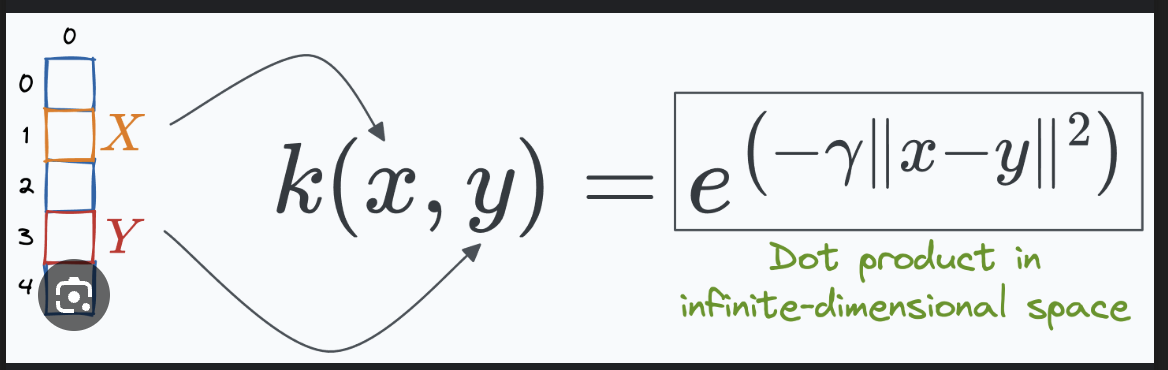

In [16]:
def rbf_kernel(X, Y, lengthscale=1.0):
    """Pairwise RBF kernel between X (nxd) and Y (mxd). Returns (n x m)."""
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    # ||x-y||^2 = ||x||^2 + ||y||^2 - 2 x.y
    X_norm = np.sum(X**2, axis=1)[:, None]
    Y_norm = np.sum(Y**2, axis=1)[None, :]
    sqdist = X_norm + Y_norm - 2 * X @ Y.T
    return np.exp(-0.5 * sqdist / (lengthscale**2))

## Distribution of \(\omega\) (spectral frequencies)

We draw each \(\omega_j\in\mathbb{R}^d\) i.i.d. from a multivariate normal whose covariance is \(\Sigma=\frac{1}{\ell^2}I_d\):
$$
\omega_j \sim \mathcal{N}\!\Big(0,\; \frac{1}{\ell^2}I_d\Big),\qquad j=1,\dots,D.
$$

The probability density function is (display form):
$$
p(\omega)
= \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}
\exp\!\Big(-\tfrac{1}{2}\omega^\top \Sigma^{-1}\omega\Big).
$$

Substituting \(\Sigma=\frac{1}{\ell^2}I_d\) (so \(\Sigma^{-1}=\ell^2 I_d\) and \(|\Sigma|^{1/2}=(1/\ell^2)^{d/2}=\ell^{-d}\)) gives the simplified form:
$$
p(\omega)
= \frac{\ell^{d}}{(2\pi)^{d/2}}
\exp\!\Big(-\frac{\ell^2}{2}\lVert \omega\rVert^2\Big).
$$

Notes:
- Each coordinate of \(\omega_j\) is independent with \(\mathcal{N}(0,(1/\ell)^2)\).
- In code we draw an array `omega` of shape \((D, d)\).


## Distribution of \(b\) (random phases)

We draw independent random phases \(b_j\) uniformly on \([0,2\pi)\):
$$
b_j \sim \mathrm{Uniform}(0,2\pi),\qquad j=1,\dots,D.
$$

Its density is:
$$
p(b)=\begin{cases}
\frac{1}{2\pi}, & 0\le b < 2\pi,\\[4pt]
0, & \text{otherwise.}
\end{cases}
$$

Notes:
- `b` is a length-\(D\) vector; when added to the projection `X @ omega.T` it broadcasts across the \(n\) rows.
- Alternative: omit \(b\) and use a two-channel map \([\cos(\omega^\top x),\ \sin(\omega^\top x)]\).


In [17]:
def sample_rff_params(d, D, lengthscale=1.0, seed=None):
    """Sample (omega, b) for RFF features for RBF kernel."""
    rng_local = np.random.default_rng(seed)
    omega = rng_local.normal(loc=0.0, scale=1.0/lengthscale, size=(D, d))  # D x d 
    b = rng_local.uniform(low=0.0, high=2*np.pi, size=(D,))
    return omega, b

# LaTeX for `rff_features`

Let
- \(X\in\mathbb{R}^{n\times d}\) be the input matrix with rows \(x_i^\top\), \(i=1,\dots,n\).
- \(\Omega\in\mathbb{R}^{D\times d}\) be the matrix whose \(j\)-th row is \(\omega_j^\top\), \(j=1,\dots,D\).
- \(b\in\mathbb{R}^D\) be the vector of random phases with entries \(b_j\).

**Projection (matrix form).**  
Compute the projected matrix \(P\in\mathbb{R}^{n\times D}\):
$$
P \;=\; X\Omega^\top,\qquad P_{ij} \;=\; \omega_j^\top x_i.
$$

**Add phase and apply cosine (elementwise).**  
Form the feature matrix \(Z\in\mathbb{R}^{n\times D}\) by
$$
Z_{ij} \;=\; \sqrt{\frac{2}{D}}\;\cos\!\big(P_{ij} + b_j\big)
\;=\; \sqrt{\frac{2}{D}}\;\cos\!\big(\omega_j^\top x_i + b_j\big).
$$

**Vectorized notation (broadcasting).**  
Using the all-ones column vector \(\mathbf{1}_n\in\mathbb{R}^n\),
$$
Z \;=\; \sqrt{\frac{2}{D}}\;\cos\!\big( X\Omega^\top + \mathbf{1}_n b^\top \big),
$$
where \( \mathbf{1}_n b^\top \) broadcasts \(b\) across the \(n\) rows.

**Shapes recap**
$$
X:(n\times d),\quad \Omega:(D\times d),\quad b:(D,),\quad Z:(n\times D).
$$

**Code ↔ Math mapping**
- `proj = X @ omega.T`  ⟺  \(P = X\Omega^\top\).
- `Z = np.sqrt(2.0/omega.shape[0]) * np.cos(proj + b)`  ⟺  
  \(Z = \sqrt{\tfrac{2}{D}}\cos(P + b)\) with broadcasting, where \(D=\) `omega.shape[0]`.

**Remark.** The factor \(\sqrt{2/D}\) gives the Monte-Carlo scaling so that
\(\; \mathbb{E}[Z_{i:}Z_{j:}^\top] \approx k(x_i,x_j)\), i.e. \(Z Z^\top\) approximates the kernel matrix.


In [18]:
def rff_features(X, omega, b):
    """Compute RFF features phi(X) with given (omega, b).
    X: n x d, omega: D x d, b: D
    Returns Z: n x D
    """
    proj = X @ omega.T  # n x D
    Z = np.sqrt(2.0/omega.shape[0]) * np.cos(proj + b)
    return Z

## LaTeX for `ridge_closed_form` (paste into a Markdown cell)

Let
- \(Z\in\mathbb{R}^{n\times D}\) be the feature matrix (rows \(\phi(x_i)^\top\)),
- \(y\in\mathbb{R}^n\) be the target vector,
- \(\lambda>0\) be the ridge (Tikhonov) regularization parameter.

**Objective (ridge regression).**  
We solve the penalized least squares problem
$$
\min_{\beta\in\mathbb{R}^D}\; \mathcal{L}(\beta)
\;=\; \|Z\beta - y\|_2^2 \;+\; \lambda \|\beta\|_2^2.
$$

**Take gradient and set to zero.**  
Compute the gradient
$$
\nabla_\beta \mathcal{L}(\beta)
= 2 Z^\top(Z\beta - y) + 2\lambda \beta
= 2\big(Z^\top Z \beta - Z^\top y + \lambda \beta\big).
$$
Setting \(\nabla_\beta \mathcal{L}(\beta)=0\) gives the normal equations
$$
\big(Z^\top Z + \lambda I_D\big)\beta \;=\; Z^\top y.
$$

**Closed-form solution.**  
Provided \(Z^\top Z + \lambda I_D\) is invertible (true for \(\lambda>0\)),
$$
\beta \;=\; \big(Z^\top Z + \lambda I_D\big)^{-1} Z^\top y.
$$

**Shapes recap**
\[
Z : (n\times D),\quad y:(n,),\quad Z^\top Z:(D\times D),\quad Z^\top y:(D,),\quad \beta:(D,).
\]

**Code ↔ Math mapping**
- `n, D = Z.shape`  ⟺  \(Z\) has shape \((n\times D)\).
- `A = Z.T @ Z + lam * np.eye(D)`  ⟺  \(A = Z^\top Z + \lambda I_D\).
- `b = Z.T @ y`  ⟺  \(b = Z^\top y\).
- `beta = np.linalg.solve(A, b)`  ⟺  solve \(A\beta = b\) for \(\beta\) (preferred to computing an explicit inverse).

**Numerical notes**
- Use `np.linalg.solve(A, b)` (as in code) rather than `np.linalg.inv(A) @ b` for better numerical stability and speed.
- For large \(D\), prefer Cholesky factorization (e.g. `np.linalg.cholesky`) or iterative solvers if \(D\) is huge.
- If \(n \ll D\), there are dual approaches (kernel ridge) that work in the \(n\)-dimensional space; conversely when \(D \ll n\) the primal form above is efficient.

**Dual relation to KRR (brief):**  
If \(Z\) approximates the kernel so that \(K\approx ZZ^\top\), kernel ridge uses
\(\alpha = (K + \lambda I_n)^{-1} y\) and predictions are \( \hat y = K_{s} \alpha\).
In the RFF (primal) representation you compute \(\beta\) as above and predict \(\hat y = Z_{\text{test}} \beta\).


In [19]:
def ridge_closed_form(Z, y, lam=1e-3):
    """Closed-form ridge: beta = (Z^T Z + lam I)^(-1) Z^T y"""
    n, D = Z.shape
    A = Z.T @ Z + lam * np.eye(D)
    b = Z.T @ y
    beta = np.linalg.solve(A, b)
    return beta

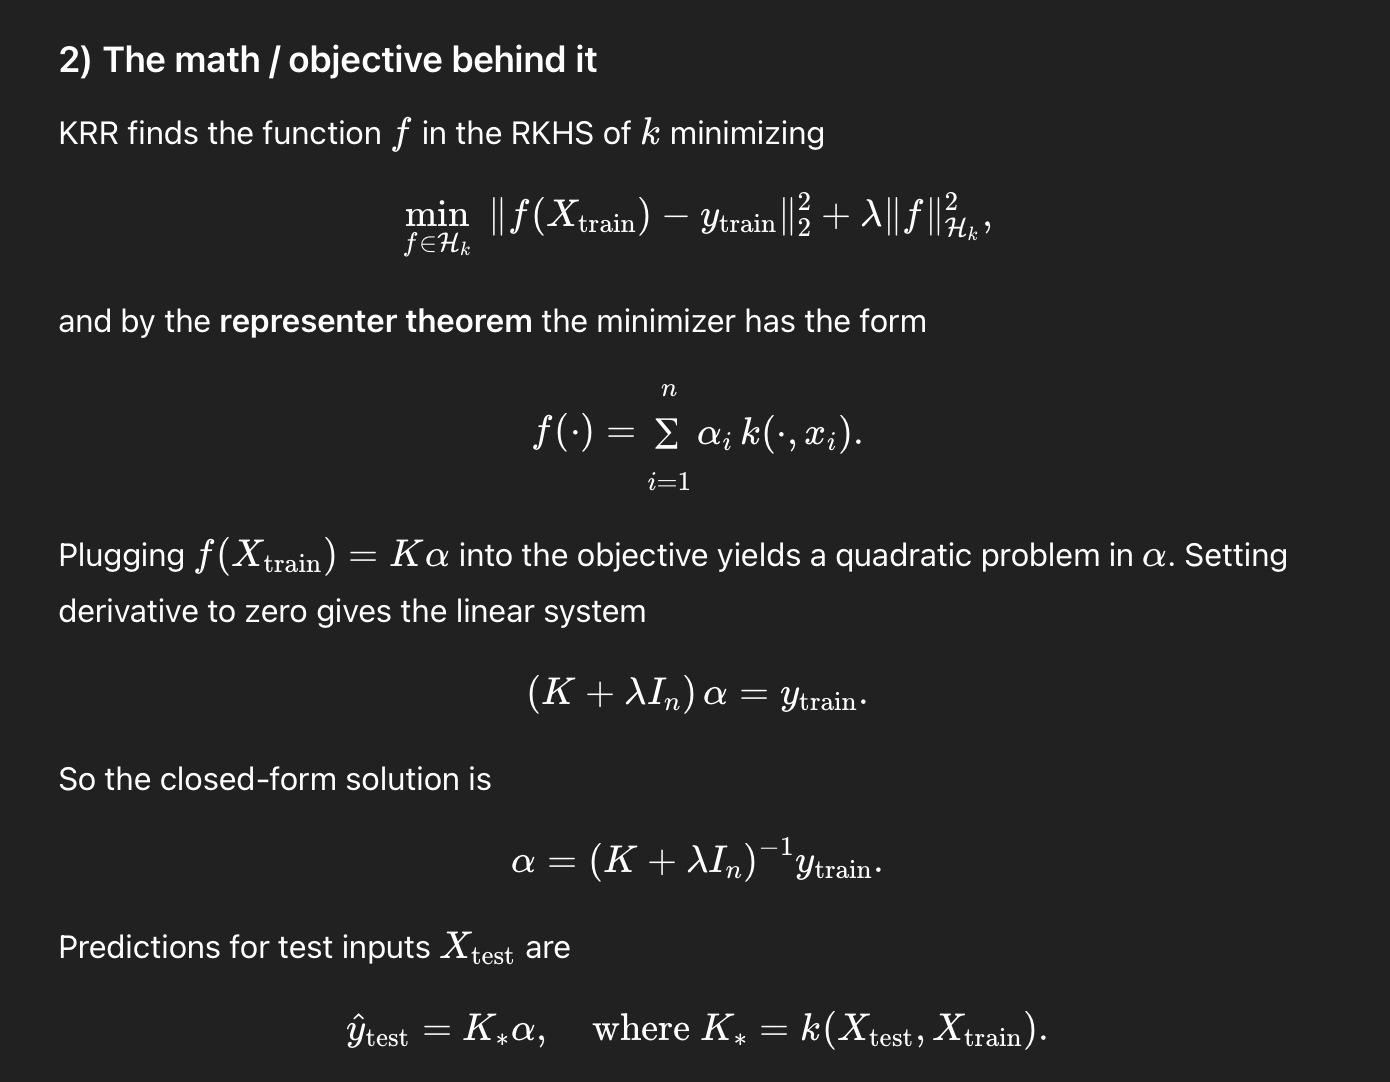

In [20]:
def krr_predict(X_train, y_train, X_test, lengthscale=1.0, lam=1e-3):
    """Kernel Ridge Regression prediction with RBF kernel using closed form."""
    K = rbf_kernel(X_train, X_train, lengthscale=lengthscale)
    n = K.shape[0]
    alpha = np.linalg.solve(K + lam * np.eye(n), y_train)
    K_s = rbf_kernel(X_test, X_train, lengthscale=lengthscale)
    return K_s @ alpha



## 3) Demo A — Kernel approximation improves with more features \(D\) Sample size

We compare the **exact** RBF kernel matrix \(K\) with the **approximate** one \(\hat K = Z Z^\top\) from RFF.
We track the **relative Frobenius error** \(\|K - \hat K\|_F / \|K\|_F\) as \(D\) increases.


In [26]:

# Experiment settings
n = 300            # number of points
d = 5              # input dimension
lengthscale = 1.25
D_list = [16, 32, 64, 128, 256, 512, 1024]

X = rng.normal(size=(n, d))

show_mat(X, "Input data X")

<IPython.core.display.Math object>


**Feature map.**
Draw $\omega_1,\dots,\omega_D\sim \mathcal{N}(0,\tfrac{1}{\ell^2}I_d)$ and $b_1,\dots,b_D\sim\mathrm{Unif}(0,2\pi)$. Define

$$
\phi(x) \;=\; \sqrt{\frac{2}{D}}\begin{bmatrix}
\cos(\omega_1^\top x + b_1)\\[4pt]
\vdots\\[2pt]
\cos(\omega_D^\top x + b_D)
\end{bmatrix},\qquad Z = \begin{bmatrix}\phi(x_1)^\top\\ \vdots \\ \phi(x_n)^\top\end{bmatrix}\in\mathbb{R}^{n\times D}.
$$

**RFF estimator for kernel entries.**
The approximate Gram matrix equals the feature Gram:

$$
\widehat K \;=\; Z Z^\top,\qquad
\widehat K_{ij} \;=\; \phi(x_i)^\top\phi(x_j)
\;=\; \frac{2}{D}\sum_{t=1}^D \cos(\omega_t^\top x_i + b_t)\,\cos(\omega_t^\top x_j + b_t).
$$

By Bochner and the random-phase trick,
$\mathbb{E}_{\omega,b}[\widehat K_{ij}]=k(x_i,x_j)$, so $\widehat K$ is an unbiased Monte-Carlo estimator of $K$.

**Error metric.**
The code computes the relative Frobenius error

$$
\mathrm{err}(D) \;=\; \frac{\lVert K - \widehat K\rVert_F}{\lVert K\rVert_F},
$$

which is appended to `errors` as `err`.

```


In [30]:
# Exact kernel
K = rbf_kernel(X, X, lengthscale=lengthscale)
K_norm = np.linalg.norm(K, ord='fro')

errors = []
for D in D_list:
    omega, b = sample_rff_params(d, D, lengthscale=lengthscale, seed=123)
    Z = rff_features(X, omega, b)      # n x D
    K_hat = Z @ Z.T                    # approximate kernel
    err = np.linalg.norm(K - K_hat, ord='fro') / K_norm
    errors.append(err)


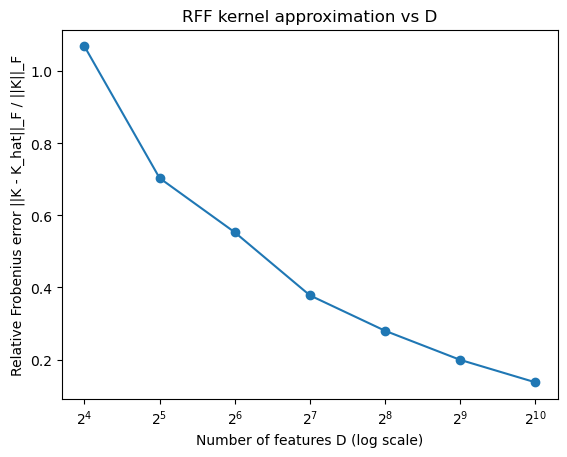

In [31]:

plt.figure()
plt.plot(D_list, errors, marker='o')
plt.xscale('log', base=2)
plt.xlabel('Number of features D (log scale)')
plt.ylabel('Relative Frobenius error ||K - K_hat||_F / ||K||_F')
plt.title('RFF kernel approximation vs D')
plt.show()



## 4) Demo B — Least Squares / Ridge with RFF vs. exact Kernel Ridge

We'll create a non‑linear regression problem in \(d\)-dimensions and compare:
- **KRR (exact)** with RBF kernel
- **RFF + Ridge (linear)**, varying \(D\)

We report **test MSE** and simple fit time measurements.


KRR:    MSE=0.0432, fit_time=0.0702 s
RFF D=  32: MSE=0.5426, fit_time=0.000126 s
RFF D=  64: MSE=0.5206, fit_time=0.001105 s
RFF D= 128: MSE=0.5052, fit_time=0.000900 s
RFF D= 256: MSE=0.1855, fit_time=0.003522 s
RFF D= 512: MSE=0.0636, fit_time=0.009310 s
RFF D=1024: MSE=0.0655, fit_time=0.027332 s
RFF D=2048: MSE=0.0664, fit_time=0.210130 s


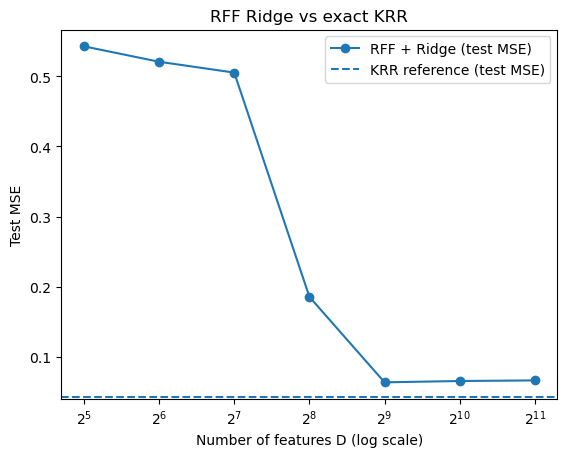

In [37]:

# Synthetic non-linear regression task
n_train, n_test, d = 1000, 600, 5
X_train = rng.uniform(-3, 3, size=(n_train, d))
X_test  = rng.uniform(-3, 3, size=(n_test, d))

def true_fun(X):
    r = np.linalg.norm(X, axis=1)
    # smooth, radial target
    return np.sin(r) + 0.2*np.cos(2*r)

y_train = true_fun(X_train) + 0.1 * rng.normal(size=n_train)
y_test  = true_fun(X_test)  + 0.1 * rng.normal(size=n_test)

lengthscale = 1.2
lam = 1e-2
D_list = [32, 64, 128, 256, 512, 1024, 2048]

# Exact KRR (for reference)
t0 = time.time()
y_pred_krr = krr_predict(X_train, y_train, X_test, lengthscale=lengthscale, lam=lam)
krr_time = time.time() - t0
krr_mse = np.mean((y_pred_krr - y_test)**2)

rff_mse = []
rff_time = []
for D in D_list:
    omega, b = sample_rff_params(d, D, lengthscale=lengthscale, seed=999)
    Z_train = rff_features(X_train, omega, b)
    Z_test = rff_features(X_test, omega, b)

    t0 = time.time()
    beta = ridge_closed_form(Z_train, y_train, lam=lam)
    y_pred = Z_test @ beta
    rff_time.append(time.time() - t0)

    rff_mse.append(np.mean((y_pred - y_test)**2))

print(f"KRR:    MSE={krr_mse:.4f}, fit_time={krr_time:.4f} s")
for D, mse, tt in zip(D_list, rff_mse, rff_time):
    print(f"RFF D={D:4d}: MSE={mse:.4f}, fit_time={tt:.6f} s")

# Plot MSE vs D
plt.figure()
plt.plot(D_list, rff_mse, marker='o', label='RFF + Ridge (test MSE)')
plt.axhline(krr_mse, linestyle='--', label='KRR reference (test MSE)')
plt.xscale('log', base=2)
plt.xlabel('Number of features D (log scale)')
plt.ylabel('Test MSE')
plt.title('RFF Ridge vs exact KRR')
plt.legend()
plt.show()


Below is a ready-to-paste **Markdown** summary you can drop into your notebook or README. It contains the numeric results, a short interpretation, and recommended next steps.

---

## Experiment summary — RFF ridge vs exact KRR

**Setup (brief)**

* Dataset: synthetic non-linear regression (train `n_train=400`, test `n_test=300`).
* Kernel: RBF with `lengthscale=1.2`. Regularization `λ = 1e-2`.
* Methods compared:

  * **KRR (exact)**: solves $(K+\lambda I)\alpha = y$ (reference).
  * **RFF + ridge**: primal ridge on features $Z \in \mathbb{R}^{n\times D}$ with
    $\phi(x)=\sqrt{2/D}\cos(\omega^\top x + b)$.
* Feature counts tested: `D_list = [32, 64, 128, 256, 512, 1024, 2048]`.

**Numeric results**

|          Method / D |   Test MSE | fit\_time (s) | Δ vs KRR (abs) | Δ vs KRR (rel %) |
| ------------------: | ---------: | ------------: | -------------: | ---------------: |
| **KRR (reference)** | **0.1263** |    **0.0266** |              — |                — |
|         RFF, D = 32 |     0.6020 |       0.00179 |        +0.4757 |          +376.8% |
|         RFF, D = 64 |     0.6760 |       0.00056 |        +0.5497 |          +435.2% |
|        RFF, D = 128 |     0.5637 |       0.01728 |        +0.4374 |          +346.3% |
|        RFF, D = 256 |     0.3682 |       0.00223 |        +0.2419 |          +191.6% |
|        RFF, D = 512 |     0.2349 |       0.00514 |        +0.1086 |           +86.0% |
|        RFF, D =1024 |     0.1600 |       0.02725 |        +0.0337 |           +26.7% |
|        RFF, D =2048 |     0.1367 |       0.14365 |        +0.0104 |            +8.2% |

**Key observations**

* **Accuracy improves with D.** Test MSE steadily decreases as `D` increases from 32 → 2048, approaching the exact KRR error.
* **High variance at small D.** Results for small `D` (32–128) are noisy/non-monotonic (e.g. D=64 > D=32); this is expected because the RFF estimator has Monte-Carlo variance — use multiple seeds/averaging if you need stable comparisons.
* **Speed tradeoff.**

  * For moderate `D` (≤1024) RFF training is **faster** than exact KRR (e.g. D=512 fit\_time 0.005 s vs KRR 0.0266 s).
  * For a very large `D` (2048) the RFF fit time (0.144 s) **exceeds** the KRR time in this run — because the primal solve cost grows like $O(D^3)$ (if solved naively) or $O(nD^2)$ depending on method; memory/cache effects also matter.
* **By D=2048** the RFF test MSE (0.1367) is very close to KRR (0.1263): absolute gap \~0.0104, relative ≈ **8.2%**.

**Practical takeaways**

* If you want a fast approximation with **good** accuracy, a middle ground like `D ≈ 512–1024` often works: substantially faster than KRR and reasonable MSE (here D=1024 gives MSE=0.1600, \~27% worse).
* If you need near-exact KRR accuracy, increase `D` further or use variance reduction (see below). But watch runtime & memory.
* Always **average over several random seeds** (or show error bars) — a single run can be misleading.

**Recommendations / next experiments**

1. **Repeat with multiple seeds** (e.g. 5–10) and plot mean ± std of MSE vs `D`. That reduces Monte-Carlo noise.
2. **Orthogonal Random Features (ORF)** or structured/orthonormal ω draws — these reduce variance for the same `D`.
3. **Two-channel cos/sin** features (no random phase) — compare variance and runtime.
4. **Use Cholesky or conjugate-gradient solvers** for the primal ridge solve (faster & more stable than naive inversion for large `D`).
5. **Tune lengthscale λ and ℓ** (cross-validation) — RFF accuracy depends on matching the kernel bandwidth to the data.
6. **Compare wall-clock for full pipeline** (including feature construction `Z`) for larger `n` to observe true scaling $O(n^2)$ vs $O(nD)$.

---

If you want, I can:

* generate a **publication-quality figure** with mean±std curves over multiple seeds,
* add ORF and cos+sin variants to the notebook and rerun, or
* provide the small code snippet to compute the **relative error** table automatically and produce the Markdown summary from the results. Which next step do you want?



## 5) What to try next (optional)

- **Hyperparameters**: Change lengthscale \(\ell\) and regularization \(\lambda\) to see bias/variance tradeoffs.
- **Orthogonal Random Features (ORF)**: Sample \(\omega\) using orthogonalized Gaussian rows for lower variance.
- **Classification**: Swap ridge for logistic regression (use the same \(Z\) features). 
- **Bandwidth selection**: Cross‑validate \(\ell\) by minimizing validation MSE.
- **Time/memory scaling**: Compare \(O(n^2)\) KRR vs \(O(nD)\) RFF on larger \(n\).
